--- Stitching Image 1 and 2 ---
Stitching images...
Keypoints found in img1: 2401
Keypoints found in img2: 2190
Good matches found: 237


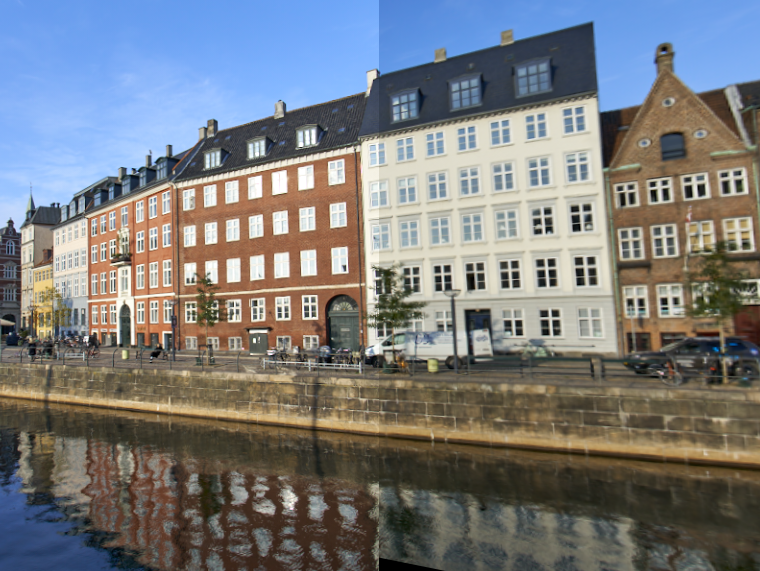


--- Stitching (1+2) and 3 ---
Stitching images...
Keypoints found in img1: 4581
Keypoints found in img2: 2448
Good matches found: 207


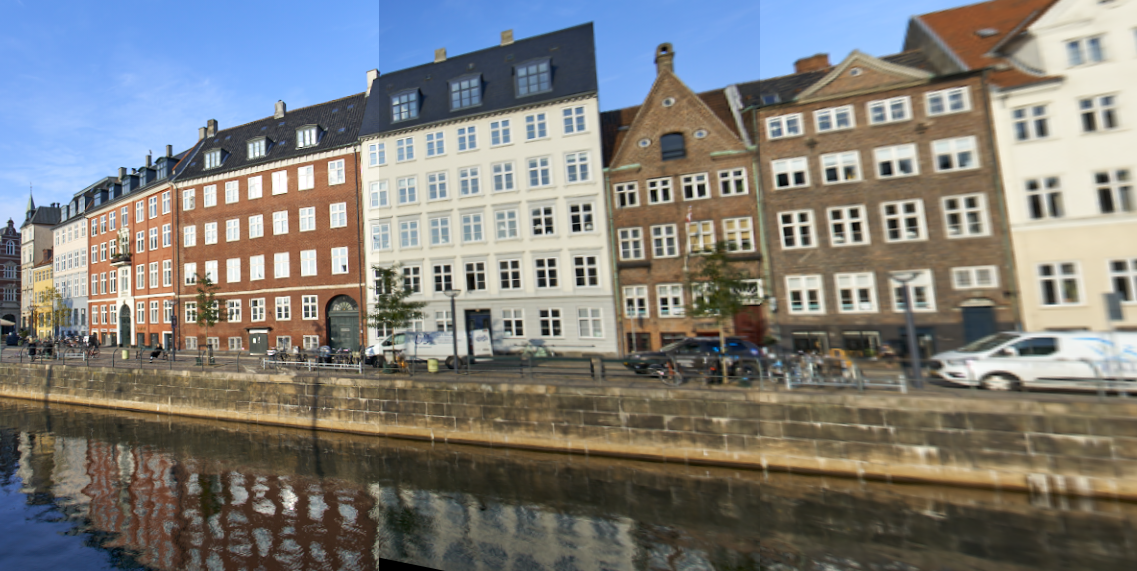


--- Stitching (1+2+3) and 4 ---
Stitching images...
Keypoints found in img1: 5631
Keypoints found in img2: 2323
Good matches found: 134

Stitching complete! Showing final panorama.


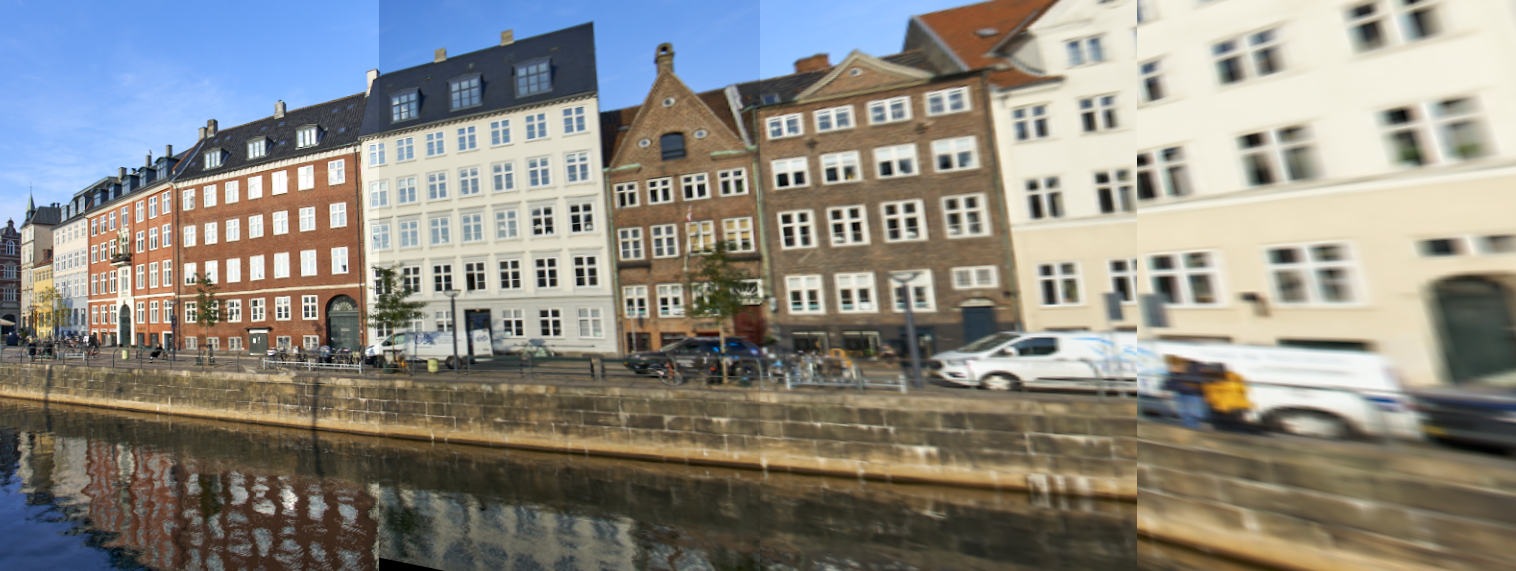

Final panorama saved as 'final_panorama.jpg'


In [6]:
import cv2
import numpy as np
import sys
from google.colab.patches import cv2_imshow

def stitch_images(img1, img2):
    """
    Stitches img2 onto img1.
    img1 is the 'base' image (e.g., left image).
    img2 is the 'secondary' image (e.g., right image) that will be warped.
    """

    print("Stitching images...")

    # 1. Feature Detection and Description
    # -------------------------------------
    # Convert images to grayscale for feature detection
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Initialize the SIFT detector
    # This is the Scale-Invariant Feature Transform
    sift = cv2.SIFT_create()

    # Find keypoints and descriptors with SIFT
    # kp = keypoints (coordinates, size, orientation)
    # des = descriptors (a 128-element vector for each keypoint)
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    print(f"Keypoints found in img1: {len(kp1)}")
    print(f"Keypoints found in img2: {len(kp2)}")

    # 2. Feature Matching
    # -------------------
    # We use BFMatcher (Brute-Force Matcher) with default params
    # It will compare every descriptor from img1 with every descriptor from img2.
    bf = cv2.BFMatcher()

    # Use k-Nearest Neighbor matching (k=2)
    # This finds the 2 best matches for each descriptor
    matches = bf.knnMatch(des1, des2, k=2)

    # Apply Lowe's Ratio Test to filter for good matches
    # This is a crucial step to remove >90% of false matches.
    # A good match (m) should be significantly better than the
    # second-best match (n).
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    print(f"Good matches found: {len(good_matches)}")

    # 3. Image Warping (Homography)
    # -----------------------------
    # We need at least 4 good matches to find the homography matrix.
    # We'll use a more stable number, e.g., 10.
    MIN_MATCH_COUNT = 10

    if len(good_matches) > MIN_MATCH_COUNT:
        # Extract the coordinates of the good matches from both images

        # queryIdx is the index of the descriptor in des1 (img1)
        # trainIdx is the index of the descriptor in des2 (img2)
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

        # Find the Homography matrix (H)
        # H maps points from img2's coordinate system to img1's coordinate system
        # cv2.RANSAC is a robust method (RANdom SAmple Consensus)
        # that ignores outliers (bad matches) when calculating the transform.
        H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

        # (Optional) Draw matches to visualize
        # matchesMask = mask.ravel().tolist()
        # draw_params = dict(matchColor=(0, 255, 0), singlePointColor=None, matchesMask=matchesMask, flags=2)
        # img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, **draw_params)
        # cv2.imshow("Good Matches", img_matches)
        # cv2.waitKey(0)

        # 4. Perform the Warp
        # -------------------
        # Get the dimensions of the images
        h1, w1 = img1.shape[:2]
        h2, w2 = img2.shape[:2]

        # Create the 'canvas' for the final panorama
        # The width is w1 + w2, and height is the max of h1 and h2
        # (A more advanced method would transform the corners of img2 to find
        # the exact required canvas size, but this is simpler.)

        # We are warping img2 to align with img1
        # The homography H maps img2_points -> img1_points
        # So, we use cv2.warpPerspective on img2
        result_canvas = cv2.warpPerspective(img2, H, (w1 + w2, h1))

        # Place the base image (img1) on the left side of the canvas
        result_canvas[0:h1, 0:w1] = img1

        # Return the stitched image
        return result_canvas

    else:
        print(f"Not enough good matches found - {len(good_matches)}/{MIN_MATCH_COUNT}")
        return None

def crop_black_padding(img):
    """Crops the black padding from a stitched image."""
    # Convert to grayscale and find the largest contour
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("No content found in image.")
        return img # Return original if no contours

    # Find the bounding box of the largest contour
    cnt = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)

    # Crop the image
    return img[y:y+h, x:x+w]

# --- MAIN EXECUTION ---
if __name__ == "__main__":

    # !!! IMPORTANT: CHANGE THESE FILE PATHS !!!
    # Let's assume you are stitching 4 images in order: 1 -> 2 -> 3 -> 4
    try:
        img1 = cv2.imread('1.png')
        img2 = cv2.imread('2.png')
        img3 = cv2.imread('3.png')
        img4 = cv2.imread('4.png')

        # Check if images loaded
        if img1 is None or img2 is None or img3 is None or img4 is None:
            raise IOError("Could not load one or more images. Check file paths.")

    except Exception as e:
        print(e)
        print("Please make sure your image files (image1.jpg, image2.jpg, etc.) are in the same directory.")
        sys.exit(1)


    print("--- Stitching Image 1 and 2 ---")
    panorama_12 = stitch_images(img1, img2)
    if panorama_12 is None:
        print("Stitching failed for 1 & 2.")
        sys.exit(1)

    # Crop black padding before next stitch
    panorama_12_cropped = crop_black_padding(panorama_12)
    cv2_imshow(panorama_12_cropped)
    cv2.waitKey(0)


    print("\n--- Stitching (1+2) and 3 ---")
    panorama_123 = stitch_images(panorama_12_cropped, img3)
    if panorama_123 is None:
        print("Stitching failed for 12 & 3.")
        sys.exit(1)

    panorama_123_cropped = crop_black_padding(panorama_123)
    cv2_imshow(panorama_123_cropped)
    cv2.waitKey(0)


    print("\n--- Stitching (1+2+3) and 4 ---")
    final_panorama = stitch_images(panorama_123_cropped, img4)
    if final_panorama is None:
        print("Stitching failed for 123 & 4.")
        sys.exit(1)

    # Crop the final result
    final_panorama_cropped = crop_black_padding(final_panorama)

    # --- Show and Save Final Result ---
    print("\nStitching complete! Showing final panorama.")
    cv2_imshow(final_panorama_cropped)
    cv2.imwrite("final_panorama.jpg", final_panorama_cropped)
    print("Final panorama saved as 'final_panorama.jpg'")

    cv2.waitKey(0)
    cv2.destroyAllWindows()